# Seaborn

- Seaborn is a Python data visualization library based on matplotlib
- It provides a high-level interface for drawing attractive and informative statistical graphics


## Scenario: IBM HR Analytics Employee Attrition and Performance


### Scenario & Tasks



Employee retention is one of the biggest metrics that a company should have in mind when thinking of growth. Employee attrition is caused when the total strength of the company is greatly reduced as more employees leave the company than expected.

So, what is **Attrition**?
It is basically the turnover rate of employees in a particular organization

Reasons for **Attrition**:

- Employees looking for better opportunities
- A negative working environment
- Bad management
- Sickness of an employee
- Excessive working hours

**Problem Statement**
Uncover the factors that lead to employee attrition and explore the reasons as to why people are leaving the organization 

**Tasks to be performed**

**Task 1:**
       
         What is the distribution of the Age & MothlyIncome columns in the data set? 
**Task 2:**   

         What's the Attrition percentage in the company? 
         Which Department of the company has the highest Attrition rate?
**Task 3:**

         Which gender is more likely to leave?
         Does distance from home affect attrition rate?
         How does the monthly income affect the attrition rate? 

**Task 4:**

         Which Employees are more likely to leave? Senior Employees or Recent Joinees, and does the years spent at the company affect Attrition?

**Task 5:**

         Are Employees in a particular Job Role more likely to quit?
         Does Job Level of employees influence Attrition rate?

**Task 6:**

         Analyze the Monthly Income of Employees in various Deparments such as Sales, Research & Development, and Human Resource?

**Task 7:**

        Analyze the impact of Age on Monthly Income using a Joint Plot

### Dataset Description

#### The is a data set contains following attributes among others

**Education**

1 'Below College'

2 'College'

3 'Bachelor'

4 'Master'

5 'Doctor'

**EnvironmentSatisfaction**

1 'Low'

2 'Medium'

3 'High'

4 'Very High'


**JobInvolvement**

1 'Low'

2 'Medium'

3 'High'

4 'Very High'


**JobSatisfaction**

1 'Low'

2 'Medium'

3 'High'

4 'Very High'


**PerformanceRating**

1 'Low'

2 'Good'

3 'Excellent'

4 'Outstanding'


**RelationshipSatisfaction**

1 'Low'

2 'Medium'

3 'High'

4 'Very High'

**WorkLifeBalance**

1 'Bad'

2 'Good'

3 'Better'

4 'Best'

### Importing Required Libraries & Loading the Dataset




In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive

In [ ]:
# !cp /content/IBM.csv /mydrive/NITW-01-Python/05-01-IBM.csv
!cp /mydrive/NITW-01-Python/05-01-IBM.csv /content/IBM.csv 

In [ ]:
!wget https://www.dropbox.com/s/53xyievbdpr7bl0/IBM.csv

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")    
import os

In [70]:
df = pd.read_csv('IBM.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
#df.dtypes
print(df.columns)

### Univariate Distributions
A Univariate distribution is a probability distribution of only one random variable

#### Task 1 : Histogram
What is the distribution of the Age & MothlyIncome columns in the data set?.



A **Histogram** visualises the distribution of data over a continuous interval or certain time period. Each bar in a histogram represents the tabulated frequency at each interval/bin. The total area of the Histogram is equal to the number of data.

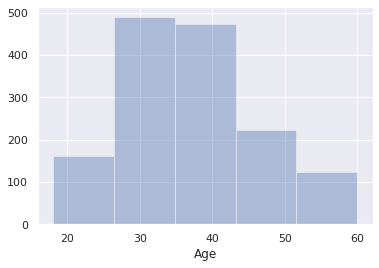

In [28]:
#from matplotlib.ticker import PercentFormatter

sns.set()
sns.distplot(df['Age'], kde=False, bins=5)
plt.show() 

- By default, **distplot** function draw a histogram and fit a kernel density estimate (KDE). In this case, the y-axis in a density plot is the probability density function
- Note that this is a probability density and not a probability. The difference is the probability density is the probability per unit on the x-axis. To convert to an actual probability, we need to find the area under the curve for a specific interval on the x-axis.
- The only requirement of the density plot is that the total area under the curve integrates to one

___
**Observations :**
- We have Employees mostly between the age of 30 to 45
___

In [ ]:
sns.set()
sns.distplot(df['MonthlyIncome'], kde = False, bins=5) 
plt.ylabel('No. of Observations')
plt.show()

___
**Observation :**
- Most of the Employees in the company earn between 2000 and 7000 monthly
- Very few Employees command a higher salary
___

#### Task 2 : Count Plot
- What's the Attrition percentage in the company? 
- Which Department of the company has the highest Attrition rate?


A **Count plot** can be thought of as a histogram across a categorical, instead of quantitative, variable.


In [11]:
print(round(df[df['Attrition']=='Yes']['Attrition'].count() * 100/len(df),0))
print(round(df[df['Attrition']=='No']['Attrition'].count() * 100/len(df),0))

16.0
84.0


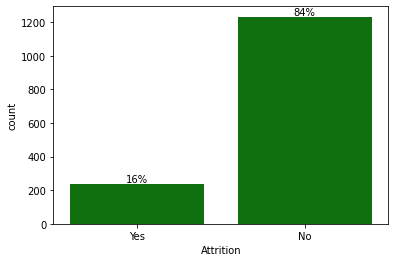

In [25]:
ax = sns.countplot(df["Attrition"], color='green')
for p in ax.patches:
    x = p.get_bbox().get_points()[:,0]
    y = p.get_bbox().get_points()[1,1]
    #print(100.*y/len(df))
    #print('{:.2g} pcnt'.format(100*y/len(df)))
    ax.annotate('{:.2g}%'.format(100.*y/len(df)), (x.mean(), y), ha='center', va='bottom')

#ax.patches[1].get_bbox().get_points()[:,1]
plt.show()

___
**Observation :**
- About **1200+** of employees did not quit the organization while about **225** did leave the organization
___

In [ ]:
sns.countplot(data=df,x=df['Department'],hue="Attrition")
plt.show()

___
**Observation :**
- Attrition raltes are high in Sales Deparment, and R&D Department as compared to HR where the attrition rate is significantly lower
___

### Bi-variate / Multivariate Distributions
- A Bi-variate distribution is a distribution of two random variables
- The concept generalizes to any number of random variables, giving a **Multivariate Distribution**

#### Task 3 : Bar Plot
- Which gender is more likely to leave?
- Does distance from home affect attrition rate?
- How does the monthly income affect the attrition rate? 



A **Barplot** is basically used to **aggregate** the categorical data according to some methods and by default it’s the **mean**

In [ ]:
sns.barplot(x = 'Attrition', y = 'MonthlyIncome', data = df)
plt.show()

___
**Observation:**
- From above, we can see that people with low monthly income are more likely to leave as compared to people with high monthly income
___

In [ ]:
# new_df = df["Gender"].groupby(df["Attrition"]).value_counts(normalize=True).rename("Percentage of group").reset_index()
new_df = df["Gender"].groupby(df["Attrition"]).value_counts(normalize=True).rename("Percentage of group").reset_index()
new_df

In [ ]:
#f,ax = plt.subplots()
ax = sns.barplot(x = "Attrition", y = "Percentage of group", hue = "Gender", data = new_df)
vals = ax.get_yticks()
print(vals)
ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])
ax.set(title = "Distribution of gender")
plt.show()

___
**Observations:**
- The company has more men than women, and so this plot tells us that men tend to leave the company more but only because they're in a larger number. This also indicates that gender might not be a key factor for employee attrition
___


In [ ]:
sns.barplot(df['Gender'],df['DistanceFromHome'],hue = df['Attrition'])
plt.show()

___
**Observations :**
- Distance from home matters more to women employees than men
- Employee are more likely to quit, when **DistanceFromHome** is above 8 km

___

#### Task 4 : Scatter Plot
Which Employees are more likely to leave? Senior Employees or Recent Joinees, and does the years spent at the company affect Attrition?


A **Scatter Plot**  shows the relationship between two variables

In [ ]:
sns.scatterplot(x=df['MonthlyIncome'],y=df['YearsAtCompany'],hue=df['Attrition'])
plt.show()

___
**Observations :**

- Majortiy of Employee fall in the monthly income category of 2500 to 10000
- Senior Employees with higher **MonthlyIncome** who have spent more number of years at company are less likely to leave as compared to recent joinees
- New Employees (less than 2 years at Company i.e., y-axis) with less **MonthlyIncome** are more likely to quit (Consider the blue dots)
- Employees with higher experience (8 to 10 years) with low wage are more likely to leave
___

#### Task 5 : Swarm Plot

- Are Employees in a particular **Job Role** more likely to quit?
- Does Job Level of employees influence Attrition rate? 

A **Swarm Plot** is a scatter plot, where one axis represents a category variable and the other axis represents a numerical variable

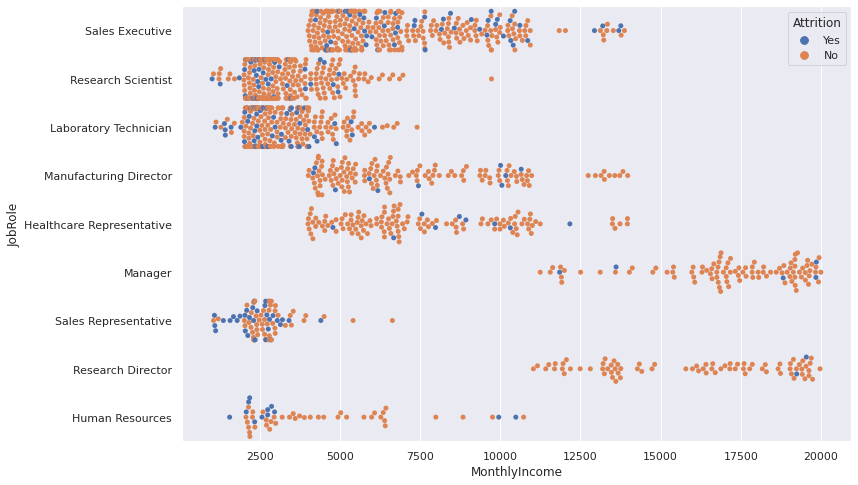

In [72]:
plt.figure(figsize=(12,8))
sns_plot = sns.swarmplot(y="JobRole", x="MonthlyIncome",hue="Attrition" ,data=df)
fig = sns_plot.get_figure()
fig.savefig("output.jpg")
#plt.xticks( rotation=50 )
plt.show()

___
**Observation :**
- Sales Representative employees are more likely to quit the organization whereas employees in **Research Director** & **Manager** position are less likely to leave

- It is significant to note that Job Roles that command a **Higher Monthly Income** (Research Director & Manager) are less likely to quit as compared to those with **Low Monthly Income** (Sales Representative)

- Attrition is high in job roles that command Low Monthly Income such as Sales Executive, Research Scientist, Laboratory Technician, Sales Representative, and Human Resources
___

In [ ]:
sns.swarmplot(x="JobLevel", y="MonthlyIncome", hue="Attrition", data=df);
plt.show()

___
**Observation :**
- Attrition rate is highest in employees at Job Level 1 positions
- It is significant to note that as Job Level increases, monthly income also increases. With the increase in Job Level (or Monthly Income), **Attrition Rate decreases**
___

#### Task 6 : Box Plot

Analyze the Monthly Income of Employees in various Deparments such as Sales, Research & Development, and Human Resource?

A **Box Plot** plots a statistical summary of one or more numerical variables

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(x="Department",y="MonthlyIncome",data=df,palette="Set2") 
#plt.xticks(rotation=90)
plt.show()

If you want to learn more about Seaborn Color palettes [**Click Here!**](https://seaborn.pydata.org/tutorial/color_palettes.html)

___
**Observation :**
- Most of the employees in various departments earn similar wage
___

#### Task 7 : Joint Plot

Analyze the impact Age on Monthly Income using a Joint Plot 

A **Joint Plot** displays a relationship amongst 2 variables (bi-variate) and a univariate distribution in the margin

In [ ]:
sns.jointplot(df.Age, df.MonthlyIncome, kind = "scatter")   
plt.show()

___
**Observation :**
- Monthly Income of Employees increase with their job level which is obvious
- Employees at Job Level 1 earn significantly less amount as compared to their bosses at level 4 & 5
___

### **Findings**

- Most of the employees are between the age of 20 & 45
- Very few employees command a higher salary as compared to most employees who earn only between 2000 and 7000 monthly 
- Attrition rate is the highest in **Research & Development** department followed by **Sales** & **Human Resource** departments
- Senior Employees with higher **MonthlyIncome** who have spent more number of years at company are less likely to leave as compared to recent joinees
- New Employees (less than 2 years at Company) with less **MonthlyIncome** are more likely to quit
- Employees with higher experience (8 to 10 years) with low wage are more likely to leave


___
###**Do It Yourself (DIY)**

Submit at least 5 new different analysis which could be performed on the above data set (along with their code in an ipynb file) that would help you gain more useful insights from the data, and their detailed observations in the markdowns

Raise a Ticket and submit this to the **Edureka's Support Team**

**Note:** Use the same ipynb for all the DIY Questions in a particular module
___


# Plotly Express

- Plotly Express is a built-in part of the plotly library, and is the recommended starting point for creating most common figures. 

- Every Plotly Express function uses graph objects internally and returns a plotly.graph_objects.Figure instance. 
- Any figure created in a single function call with Plotly Express could be created using graph objects alone, but with between 5 and 100 times more code.




## Explore the Gapminder Dataset with Plotly Express


### Dataset Description

It provides data about the population, life expectancy and GDP in different countries of the world from 1952 to 2007. 

The dataset contains - 

- **country** - Name of the Country
- **continent** - Name of the Continent
- **year** - Year
- **lifeExp** - Life Expectancy
- **pop** - Population
- **gdpPercap** - GDP per capita

### Imports

In [46]:
import pandas as pd
import numpy as np

from plotly.figure_factory import create_table
import plotly.express as px

In [47]:
gapminder = px.data.gapminder()
print(gapminder.shape)
gapminder.head()

(1704, 8)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [31]:
print(gapminder.continent.unique())

['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']


In [33]:
gapminder[gapminder['continent'] == 'Asia']['country'].unique()

array(['Afghanistan', 'Bahrain', 'Bangladesh', 'Cambodia', 'China',
       'Hong Kong, China', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel',
       'Japan', 'Jordan', 'Korea, Dem. Rep.', 'Korea, Rep.', 'Kuwait',
       'Lebanon', 'Malaysia', 'Mongolia', 'Myanmar', 'Nepal', 'Oman',
       'Pakistan', 'Philippines', 'Saudi Arabia', 'Singapore',
       'Sri Lanka', 'Syria', 'Taiwan', 'Thailand', 'Vietnam',
       'West Bank and Gaza', 'Yemen, Rep.'], dtype=object)

###Visualizations with Bar Charts


In [48]:
data_canada = px.data.gapminder().query("country == 'Canada'")
fig = px.bar(data_canada, x='year', y='pop', height=400)
fig.show()

In [49]:
fig = px.bar(data_canada, x='year', y='pop',
             hover_data=['lifeExp', 'gdpPercap'], color='lifeExp')
fig.show()

###Plot Life Expectancy vs GDP per Capita for the year 2007

In [50]:
gapminder2007 = gapminder.query("year == 2007")

px.scatter(gapminder2007, x="gdpPercap", y="lifeExp")

In [51]:
px.scatter(gapminder2007, x="gdpPercap", y="lifeExp", color="continent", hover_name='country')

### Animated Bubble Chart


In [53]:
px.scatter(gapminder2007, x="gdpPercap", y="lifeExp", color="continent", size="pop", size_max=60, hover_name="country")

In [57]:
px.scatter(gapminder, x="gdpPercap", y="lifeExp",size="pop", size_max=60, color="continent", hover_name="country",
           animation_frame="year", animation_group="country", log_x=True, range_x=[100,100000], range_y=[25,90],
           labels=dict(pop="Population", gdpPercap="GDP per Capita", lifeExp="Life Expectancy"))


### Animated Facet plot


In [58]:
px.scatter(gapminder2007, x="gdpPercap", y="lifeExp", color="continent", size="pop", size_max=60,
          hover_name="country", facet_col="continent", log_x=True)

In [59]:
fig = px.scatter(gapminder, x="gdpPercap", y="lifeExp", animation_frame="year", animation_group="country",
           size="pop", color="continent", hover_name="country", facet_col="continent",
           log_x=True, size_max=45, range_x=[100,100000], range_y=[25,90])
fig.show()

###Represent Geographic Data as Animated Maps


In [61]:
px.choropleth(gapminder2007, locations="iso_alpha", color="lifeExp", hover_name="country",
              range_color=[20,80], projection="natural earth")

In [62]:
px.choropleth(gapminder, locations="iso_alpha", color="lifeExp", hover_name="country", animation_frame='year',
              range_color=[20,80], projection="natural earth")


### Line Plot and Area Plot

In [66]:
gapminder.query("continent == 'Europe'" )

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
12,Albania,Europe,1952,55.230,1282697,1601.056136,ALB,8
13,Albania,Europe,1957,59.280,1476505,1942.284244,ALB,8
14,Albania,Europe,1962,64.820,1728137,2312.888958,ALB,8
15,Albania,Europe,1967,66.220,1984060,2760.196931,ALB,8
16,Albania,Europe,1972,67.690,2263554,3313.422188,ALB,8
...,...,...,...,...,...,...,...,...
1603,United Kingdom,Europe,1987,75.007,56981620,21664.787670,GBR,826
1604,United Kingdom,Europe,1992,76.420,57866349,22705.092540,GBR,826
1605,United Kingdom,Europe,1997,77.218,58808266,26074.531360,GBR,826
1606,United Kingdom,Europe,2002,78.471,59912431,29478.999190,GBR,826


In [68]:
fig = px.line(gapminder.query("continent == 'Europe'" ), x="year", y="lifeExp", color="country", line_group="country", hover_name="country",
        line_shape="spline", render_mode="svg")
fig.show()

In [69]:
fig = px.area(gapminder, x="year", y="pop", color="continent", line_group="country")
fig.show()

## Some Basic Plots in Plotly Express




Plotly Express is the easy-to-use, high-level interface to Plotly, which operates on a variety of types of data and produces easy-to-style figures.

With px.scatter, each data point is represented as a marker point, whose location is given by the x and y columns.


### **1. Scatter Plot**


In [ ]:
x = list(df['Age'])
y = list(df['MonthlyIncome'])
print(len(x), len(y))

In [ ]:
# x and y given as array_like objects
import plotly.express as px
#fig = px.scatter(x=[0, 1, 2, 3, 4], y=[0, 1, 4, 9, 16])
fig = px.scatter(x[:200], y[:200])
fig.show()

Set size and color with column names

Note that color and size data are added to hover information. You can add other columns to hover data with the hover_data argument of px.scatter.

In [ ]:
df = px.data.iris()
print(df.shape)
df.head()

In [ ]:
# This Plot is also Known as Bubble Chart
df = px.data.iris()
#fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species",
#                 size='petal_length', hover_data=['petal_width'])

fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species")
fig.show()

In [ ]:
#Bubble Chart

import plotly.express as px
df = px.data.gapminder()

fig = px.scatter(df.query("year==2007"), x="gdpPercap", y="lifeExp", size="pop", color="continent",
                 hover_name="country", log_x=True, size_max=60)
fig.show()

###**2. Line plot**

In [ ]:
import plotly.express as px
fig = px.line(x=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June'], y= ['70', '40', '32', '66','58','27'], labels={'x':'Months', 'y':'Sales (in Millions)'})
fig.show()

In [ ]:
import numpy as np

t = np.linspace(0, 2*np.pi, 100)

fig = px.line(x=t, y=np.cos(t), labels={'x':'t', 'y':'cos(t)'})
fig.show()

In [ ]:
import plotly.express as px

df = px.data.gapminder().query("country=='Canada'")
fig = px.line(df, x="year", y="lifeExp", title='Life expectancy in Canada')
fig.show()

In [ ]:
# Line Plot with column encoding color

import plotly.express as px

df = px.data.gapminder().query("continent=='Oceania'")
fig = px.line(df, x="year", y="lifeExp", color='country')
fig.show()

In [ ]:
import plotly.express as px

df = px.data.gapminder().query("continent != 'Asia'") # remove Asia for visibility
fig = px.line(df, x="year", y="lifeExp", color="continent",
              line_group="country", hover_name="country")
fig.show()

###**3. Bar Plot**

In [ ]:
fig = px.bar(x=[0, 1, 2, 3, 4], y=[10, 20, 30, 40, 16])
fig.show()

In [ ]:
import plotly.express as px
data_canada = px.data.gapminder().query("country == 'Canada'")
fig = px.bar(data_canada, x='year', y='pop')
fig.show()

In [ ]:
import plotly.express as px
df = px.data.tips()
fig = px.bar(df, x="total_bill", y="day", orientation='h')
fig.show()

###**4. Pie Chart**

In [35]:
import plotly.express as px
df = px.data.gapminder().query("year == 2007").query("continent == 'Europe'")
#df.loc[df['pop'] < 2.e6, 'country'] = 'Other countries' # Represent only large countries
fig = px.pie(df, values='pop', names='country', title='Population of European continent')
fig.show()

In [37]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [36]:
# This dataframe has 244 lines, but 4 distinct values for `day`
df = px.data.tips()
fig = px.pie(df, values='tip', names='day')
fig.show()

In [41]:
# Setting the color of pie sectors with px.pie
import plotly.express as px
df = px.data.tips()
#fig = px.pie(df, values='tip', names='day', color_discrete_sequence=px.colors.sequential.RdBu)
fig = px.pie(df, values='tip', names='day', color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

###**5. Filled Area Plots**

In [42]:
import plotly.express as px
df = px.data.gapminder()
fig = px.area(df, x="year", y="pop", color="continent",line_group="country")
fig.show()

###**6. Box Plot**


In [ ]:
#In a box plot created by px.box, the distribution of the column given as y argument is represented
df = px.data.tips()
fig = px.box(df, y="total_bill")
fig.show()

###**7. Histogram**

In [ ]:
df = px.data.tips()
fig = px.histogram(df, x="total_bill")
fig.show()

###**8. Heat Map**

In [43]:
import plotly.express as px

fig = px.imshow([[1, 20, 30],
                 [20, 1, 60],
                 [30, 60, 1]])
fig.show()

###**9. Violin Plot**

In [44]:
import plotly.express as px

df = px.data.tips()
fig = px.violin(df, y="total_bill")
fig.show()

###**10. Basic Dot Plot**



Dot plots (also known as Cleveland dot plots) show changes between two (or more) points in time or between two (or more) conditions. Compared to a bar chart, dot plots can be less cluttered and allow for an easier comparison between conditions.

For the same data, we show below how to create a dot plot using either px.scatter or go.Scatter.

Plotly Express is the easy-to-use, high-level interface to Plotly, which operates on a variety of types of data and produces easy to style figures

In [ ]:
import plotly.express as px
import pandas as pd

schools = ["Brown", "NYU", "Notre Dame", "Cornell", "Tufts", "Yale",
           "Dartmouth", "Chicago", "Columbia", "Duke", "Georgetown",
           "Princeton", "U.Penn", "Stanford", "MIT", "Harvard"]
n_schools = len(schools)

men_salary = [72, 67, 73, 80, 76, 79, 84, 78, 86, 93, 94, 90, 92, 96, 94, 112]
women_salary = [92, 94, 100, 107, 112, 114, 114, 118, 119, 124, 131, 137, 141, 151, 152, 165]

df = pd.DataFrame(dict(school=schools*2, salary=men_salary + women_salary,
                       gender=["Men"]*n_schools + ["Women"]*n_schools))


In [ ]:
df.tail()

In [ ]:
# Use column names of df for the different parameters x, y, color, ...
fig = px.scatter(df, x="salary", y="school", color="gender",
                 title="Gender Earnings Disparity",
                 labels={"salary":"Annual Salary (in thousands)"} # customize axis label
                )

fig.show()